## Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

Vamos começar carregando o dataset MNIST usando `sklearn.datasets.fetch_openml` e exibindo as dimensões das matrizes (X e y).

In [49]:
from sklearn.datasets import fetch_openml

print("Baixando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("Finalizou o processo de baixar o dataset MNIST!")

X, y = mnist.data, mnist.target

print(f"Dimensionalidade de X: {X.shape}")
print(f"Dimensionalidade de y: {y.shape}")

Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!
Dimensionalidade de X: (70000, 784)
Dimensionalidade de y: (70000,)


### Distribuição das Classes (Balanceamento)

Vamos verificar a distribuição dos dígitos (classes) para garantir que o dataset esteja balanceado.

Distribuição das classes (dígitos):
0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
Name: count, dtype: int64


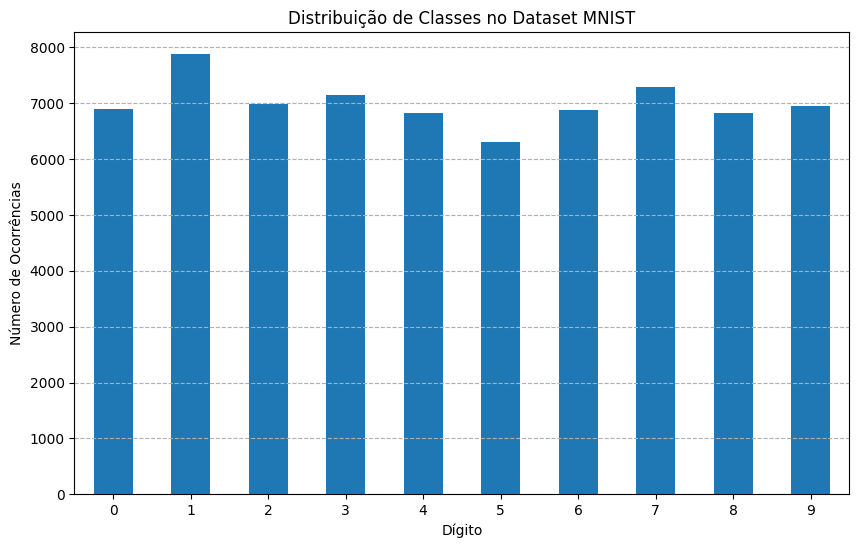

In [50]:
import pandas as pd

# Convertendo y para tipo numérico para contagem
y_numeric = y.astype(int)

# Contando a ocorrência de cada dígito
class_distribution = pd.Series(y_numeric).value_counts().sort_index()

print("Distribuição das classes (dígitos):")
print(class_distribution)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
class_distribution.plot(kind='bar')
plt.title('Distribuição de Classes no Dataset MNIST')
plt.xlabel('Dígito')
plt.ylabel('Número de Ocorrências')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.show()

### Grade Visual de Exemplos de Imagens

Vamos visualizar algumas imagens de exemplo para cada dígito para entender melhor a natureza dos dados.

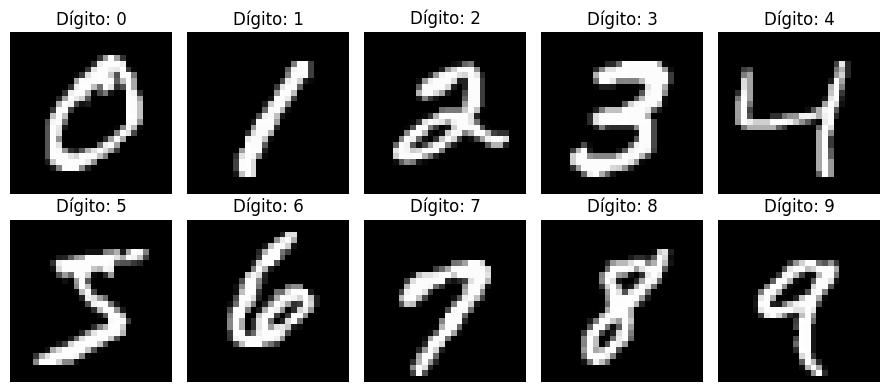

In [51]:
import numpy as np
import matplotlib.pyplot as plt

def plot_digits(X, y, n_rows=2, n_cols=5):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.8, n_rows * 2))
    axes = axes.flatten()

    for i in range(10):
        # Encontrar um índice para o dígito atual
        idx = np.where(y == str(i))[0][0] # Converter 'y' para string para comparação

        # Reshape the 784-dimensional vector to a 28x28 image
        image = X[idx].reshape(28, 28)

        axes[i].imshow(image, cmap='gray')
        axes[i].set_title(f"Dígito: {y[idx]}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Chamar a função para plotar a grade
plot_digits(X, y)


### Interpretação da Estrutura dos Dados

O dataset MNIST é composto por 70.000 imagens em escala de cinza, cada uma com 28x28 pixels. Essas imagens são representadas de duas formas principais no dataset:

*   **Matriz Bidimensional (28x28 pixels):** Cada imagem é originalmente uma grade de 28 linhas por 28 colunas de pixels. Cada pixel possui um valor de intensidade que varia de 0 a 255.
    *   **Escala de Intensidade (0 a 255):** O valor 0 geralmente representa a cor preta (ausência de luz ou tinta), enquanto o valor 255 representa a cor branca (intensidade máxima de luz). Valores intermediários indicam tons de cinza. Esta escala é importante porque modelos de Machine Learning geralmente funcionam melhor com valores normalizados, como veremos na próxima fase.

*   **Representação Vetorial (784 features):** Para facilitar o uso em algoritmos de Machine Learning, as imagens bidimensionais de 28x28 pixels são "achatadas" ou vetorizadas em um único vetor unidimensional de 784 elementos (28 * 28 = 784). Cada elemento desse vetor corresponde à intensidade de um pixel na imagem original. É por isso que `X.shape` mostrou (70000, 784), indicando 70.000 imagens, cada uma com 784 características (pixels).

## Fase 2: Pipeline de Pré-processamento e Divisão dos Dados

Nesta fase, iremos preparar os dados para o treinamento dos modelos, realizando a divisão estratificada e a normalização dos valores de pixel.

### Divisão Estratificada dos Dados

Dividiremos o dataset em conjuntos de treino, validação e teste. É crucial usar a estratificação (`stratify=y`) para garantir que cada conjunto tenha uma proporção similar de cada classe (dígito), mantendo o balanceamento observado na Fase 1.

In [52]:
from sklearn.model_selection import train_test_split

# Convertendo y para tipo int para o stratify
y_int = y.astype(int)

# Dividir em treino (80%) e teste (20%) - seguindo uma das opções do requisito
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y_int, test_size=0.2, random_state=42, stratify=y_int)

# Dividir o conjunto de treino+validação (80%) em treino (70% do total) e validação (10% do total)
# Isso significa que o conjunto de validação será 10/80 = 1/8 do conjunto X_train_val
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=(0.1/0.8), random_state=42, stratify=y_train_val)

print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de X_val: {X_val.shape}")
print(f"Shape de y_val: {y_val.shape}")
print(f"Shape de X_test: {X_test.shape}")
print(f"Shape de y_test: {y_test.shape}")


Shape de X_train: (49000, 784)
Shape de y_train: (49000,)
Shape de X_val: (7000, 784)
Shape de y_val: (7000,)
Shape de X_test: (14000, 784)
Shape de y_test: (14000,)


### Normalização / Escalonamento dos Pixels

Os valores dos pixels atualmente variam de 0 a 255. Para otimizar o desempenho de muitos algoritmos de Machine Learning (especialmente os lineares e redes neurais), é fundamental normalizá-los para um intervalo padrão, como [0.0, 1.0].


In [53]:
# Normalizar os valores dos pixels para o intervalo [0.0, 1.0]
X_train_scaled = X_train / 255.0
X_val_scaled = X_val / 255.0
X_test_scaled = X_test / 255.0

print(f"Primeiro pixel de X_train antes da normalização: {X_train[0][0]}")
print(f"Primeiro pixel de X_train_scaled após normalização: {X_train_scaled[0][0]}")


Primeiro pixel de X_train antes da normalização: 0
Primeiro pixel de X_train_scaled após normalização: 0.0


### Justificativa da Importância da Normalização

A normalização dos dados é uma etapa crítica no pré-processamento por várias razões:

1.  **Convergência de Modelos:** Para algoritmos que utilizam gradientes (como Redes Neurais e Regressão Logística), a normalização garante que as atualizações de peso durante o treinamento sejam mais estáveis e rápidas. Se os dados tiverem diferentes escalas, as features com valores maiores podem dominar a função de custo, levando a um treinamento mais lento ou a problemas de convergência.

2.  **Modelos Baseados em Distância:** Algoritmos como K-Nearest Neighbors (KNN) e Support Vector Machines (SVM) calculam distâncias entre os pontos de dados. Sem normalização, features com escalas maiores teriam uma influência desproporcionalmente maior no cálculo da distância, subestimando a importância de features com escalas menores.

3.  **Redução de Viés:** Garante que nenhuma feature individual (pixel, neste caso) domine o processo de aprendizagem apenas por ter um intervalo de valores maior. Todos os pixels contribuem igualmente para o modelo em termos de sua escala.

4.  **Melhora do Desempenho:** Na prática, a normalização geralmente leva a modelos com melhor desempenho, mais robustos e mais rápidos para treinar.

## Fase 3: Implementação e Treinamento dos 3 Modelos

Nesta fase, iremos implementar e treinar três modelos de classificação distintos para o dataset MNIST. Cada modelo terá seus hiperparâmetros ajustados e justificativas para as escolhas.

### Modelo 1: Support Vector Machine (SVM)

**Justificativa:** O SVM é um algoritmo poderoso para tarefas de classificação, especialmente em espaços de alta dimensão. É conhecido por sua capacidade de encontrar um hiperplano ótimo que separa as classes, maximizando a margem entre elas. Embora computacionalmente intensivo para grandes datasets, pode oferecer excelente precisão.

**Hiperparâmetros a serem ajustados:**
*   `C`: Parâmetro de regularização. Um `C` menor incentiva uma margem maior e mais erros de classificação no conjunto de treino, enquanto um `C` maior busca minimizar os erros de classificação, potencialmente levando a um overfitting.
*   `kernel`: O tipo de função kernel a ser usado. O kernel 'rbf' (Radial Basis Function) é popular por sua capacidade de mapear dados para um espaço de dimensão superior, permitindo a separação de classes não linearmente separáveis.

In [54]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time

print("Treinando SVM...")
start_time = time.time()

# Escolha de hiperparâmetros: C=100 (menos regularização, foco em classificar corretamente o treino), kernel='rbf' (para capturar relações não lineares)
svm_model = SVC(C=100, kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

end_time = time.time()
training_time_svm = end_time - start_time
print(f"Tempo de treinamento do SVM: {training_time_svm:.2f} segundos")

# Avaliar no conjunto de validação
y_val_pred_svm = svm_model.predict(X_val_scaled)
accuracy_svm = accuracy_score(y_val, y_val_pred_svm)
print(f"Acurácia do SVM no conjunto de validação: {accuracy_svm:.4f}")


Treinando SVM...
Tempo de treinamento do SVM: 201.75 segundos
Acurácia do SVM no conjunto de validação: 0.9814


### Modelo 2: Random Forest Classifier

**Justificativa:** Random Forest é um algoritmo de aprendizado de ensemble que constrói múltiplas árvores de decisão e combina suas previsões para melhorar a acurácia e controlar o overfitting. É robusto, fácil de usar e geralmente apresenta bom desempenho em uma variedade de datasets.

**Hiperparâmetros a serem ajustados:**
*   `n_estimators`: O número de árvores na floresta. Um número maior de árvores geralmente leva a um desempenho melhor, mas também aumenta o tempo computacional.
*   `max_depth`: A profundidade máxima de cada árvore. Limitar a profundidade ajuda a evitar o overfitting, controlando a complexidade do modelo.

In [55]:
from sklearn.ensemble import RandomForestClassifier

print("Treinando Random Forest...")
start_time = time.time()

# Escolha de hiperparâmetros: n_estimators=200 (maior número de árvores para melhor generalização), max_depth=20 (profundidade limitada para evitar overfitting)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1) # n_jobs=-1 usa todos os cores disponíveis
rf_model.fit(X_train_scaled, y_train)

end_time = time.time()
training_time_rf = end_time - start_time
print(f"Tempo de treinamento do Random Forest: {training_time_rf:.2f} segundos")

# Avaliar no conjunto de validação
y_val_pred_rf = rf_model.predict(X_val_scaled)
accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
print(f"Acurácia do Random Forest no conjunto de validação: {accuracy_rf:.4f}")


Treinando Random Forest...
Tempo de treinamento do Random Forest: 72.10 segundos
Acurácia do Random Forest no conjunto de validação: 0.9667


### Modelo 3: Multi-layer Perceptron (MLP) Classifier

**Justificativa:** Um Perceptron Multicamadas (MLP) é uma classe de redes neurais feedforward. É uma boa opção para começar com Deep Learning devido à sua simplicidade e capacidade de aprender mapeamentos não lineares complexos dos dados. É um excelente benchmark para modelos clássicos.

**Hiperparâmetros a serem ajustados:**
*   `hidden_layer_sizes`: A arquitetura das camadas ocultas. Define o número de neurônios em cada camada oculta. Uma ou duas camadas ocultas com um número razoável de neurônios são geralmente suficientes para este tipo de problema.
*   `activation`: A função de ativação para as camadas ocultas. A 'relu' (Rectified Linear Unit) é uma escolha comum e eficaz que ajuda a combater o problema do gradiente evanescente.
*   `solver`: O algoritmo para otimização de peso. 'adam' é um otimizador popular que geralmente funciona bem na prática.

In [56]:
from sklearn.neural_network import MLPClassifier

print("Treinando MLP Classifier...")
start_time = time.time()

# Escolha de hiperparâmetros: hidden_layer_sizes=(100,) (uma camada oculta com 100 neurônios), activation='relu', solver='adam'
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=200, random_state=42, verbose=True)
mlp_model.fit(X_train_scaled, y_train)

end_time = time.time()
training_time_mlp = end_time - start_time
print(f"Tempo de treinamento do MLP Classifier: {training_time_mlp:.2f} segundos")

# Avaliar no conjunto de validação
y_val_pred_mlp = mlp_model.predict(X_val_scaled)
accuracy_mlp = accuracy_score(y_val, y_val_pred_mlp)
print(f"Acurácia do MLP Classifier no conjunto de validação: {accuracy_mlp:.4f}")


Treinando MLP Classifier...
Iteration 1, loss = 0.48795459
Iteration 2, loss = 0.22786036
Iteration 3, loss = 0.17605494
Iteration 4, loss = 0.14479168
Iteration 5, loss = 0.12184589
Iteration 6, loss = 0.10422199
Iteration 7, loss = 0.08958563
Iteration 8, loss = 0.07802424
Iteration 9, loss = 0.06975169
Iteration 10, loss = 0.06113587
Iteration 11, loss = 0.05460404
Iteration 12, loss = 0.04814680
Iteration 13, loss = 0.04336161
Iteration 14, loss = 0.03846376
Iteration 15, loss = 0.03452774
Iteration 16, loss = 0.03064341
Iteration 17, loss = 0.02759552
Iteration 18, loss = 0.02524666
Iteration 19, loss = 0.02182266
Iteration 20, loss = 0.01962742
Iteration 21, loss = 0.01732054
Iteration 22, loss = 0.01560987
Iteration 23, loss = 0.01330875
Iteration 24, loss = 0.01253395
Iteration 25, loss = 0.01167094
Iteration 26, loss = 0.00978273
Iteration 27, loss = 0.00895707
Iteration 28, loss = 0.00785985
Iteration 29, loss = 0.00709235
Iteration 30, loss = 0.00583438
Iteration 31, loss = 

## Fase 4: Avaliação Comparativa de Desempenho

Nesta fase, avaliaremos o desempenho final de cada um dos três modelos no conjunto de teste independente (`X_test_scaled`, `y_test`), que não foi utilizado durante o treinamento ou validação. Analisaremos a matriz de confusão, métricas de desempenho e faremos uma conclusão comparativa.

### Matrizes de Confusão e Métricas de Desempenho no Conjunto de Teste

Vamos gerar as previsões para cada modelo no `X_test_scaled` e então calcular a matriz de confusão e o relatório de classificação para cada um.

Avaliando SVM no conjunto de teste...

--- SVM Classifier ---

Classification Report (SVM):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1381
           1       0.99      0.99      0.99      1575
           2       0.98      0.98      0.98      1398
           3       0.99      0.98      0.98      1428
           4       0.98      0.98      0.98      1365
           5       0.98      0.98      0.98      1263
           6       0.99      0.99      0.99      1375
           7       0.98      0.98      0.98      1459
           8       0.98      0.98      0.98      1365
           9       0.98      0.97      0.97      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



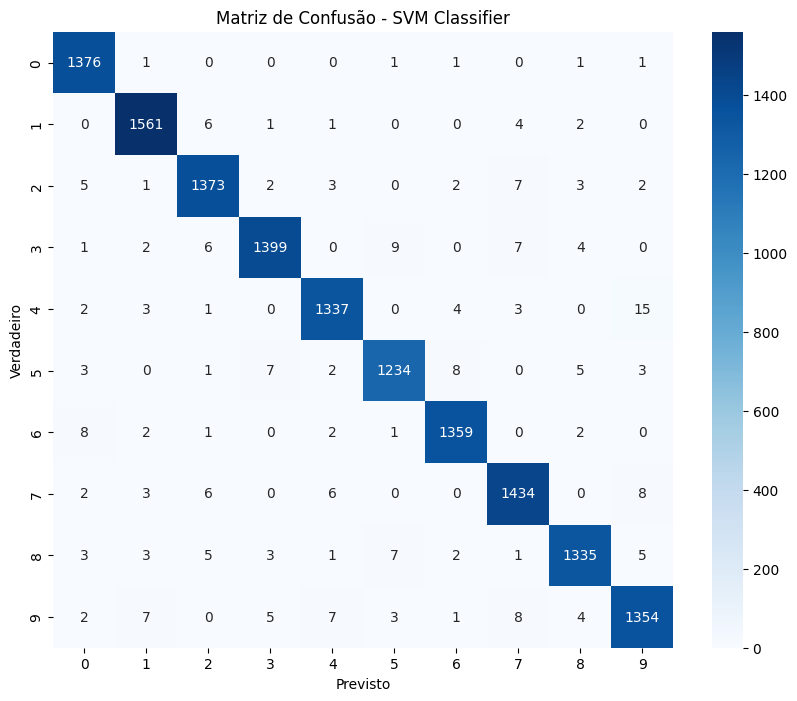


Avaliando Random Forest no conjunto de teste...

--- Random Forest Classifier ---

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1381
           1       0.98      0.98      0.98      1575
           2       0.96      0.97      0.96      1398
           3       0.96      0.96      0.96      1428
           4       0.97      0.96      0.96      1365
           5       0.97      0.95      0.96      1263
           6       0.97      0.98      0.97      1375
           7       0.97      0.96      0.97      1459
           8       0.96      0.95      0.95      1365
           9       0.93      0.95      0.94      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



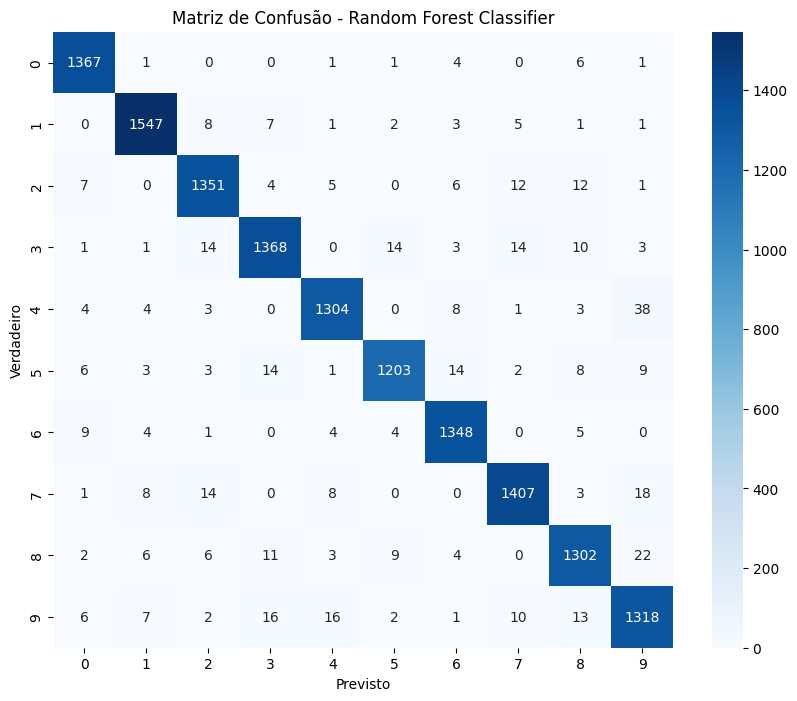


Avaliando MLP Classifier no conjunto de teste...

--- MLP Classifier ---

Classification Report (MLP):
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1381
           1       0.98      0.99      0.99      1575
           2       0.98      0.98      0.98      1398
           3       0.98      0.97      0.97      1428
           4       0.97      0.97      0.97      1365
           5       0.97      0.97      0.97      1263
           6       0.99      0.99      0.99      1375
           7       0.97      0.98      0.97      1459
           8       0.98      0.96      0.97      1365
           9       0.96      0.96      0.96      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



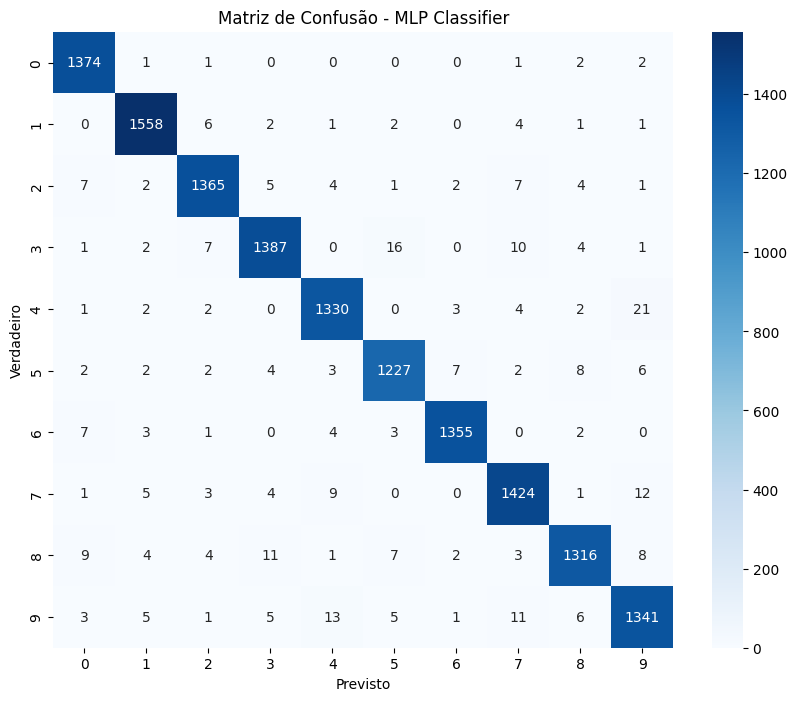

In [57]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --- SVM Model Evaluation ---
print("Avaliando SVM no conjunto de teste...")
y_test_pred_svm = svm_model.predict(X_test_scaled)

print("\n--- SVM Classifier ---")
print("\nClassification Report (SVM):")
print(classification_report(y_test, y_test_pred_svm))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_test_pred_svm), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - SVM Classifier')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.show()

# --- Random Forest Model Evaluation ---
print("\nAvaliando Random Forest no conjunto de teste...")
y_test_pred_rf = rf_model.predict(X_test_scaled)

print("\n--- Random Forest Classifier ---")
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_test_pred_rf))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_test_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Random Forest Classifier')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.show()

# --- MLP Model Evaluation ---
print("\nAvaliando MLP Classifier no conjunto de teste...")
y_test_pred_mlp = mlp_model.predict(X_test_scaled)

print("\n--- MLP Classifier ---")
print("\nClassification Report (MLP):")
print(classification_report(y_test, y_test_pred_mlp))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_test_pred_mlp), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - MLP Classifier')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.show()


### Tabela Comparativa Consolidada de Desempenho

Vamos consolidar as métricas de desempenho chave (Acurácia Global, Precisão Média Ponderada, Revocação Média Ponderada, F1-Score Ponderado) para todos os modelos em uma única tabela para facilitar a comparação.

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Function to get metrics from classification report
def get_metrics(y_true, y_pred, model_name, training_time):
    report = classification_report(y_true, y_pred, output_dict=True)
    accuracy = accuracy_score(y_true, y_pred)
    precision_weighted = report['weighted avg']['precision']
    recall_weighted = report['weighted avg']['recall']
    f1_weighted = report['weighted avg']['f1-score']

    return {
        'Modelo': model_name,
        'Acurácia Global': accuracy,
        'Precisão Média Ponderada': precision_weighted,
        'Revocação Média Ponderada': recall_weighted,
        'F1-Score Ponderado': f1_weighted,
        'Tempo de Treinamento (s)': training_time
    }

# Collecting metrics for each model
metrics_svm = get_metrics(y_test, y_test_pred_svm, 'SVM', training_time_svm)
metrics_rf = get_metrics(y_test, y_test_pred_rf, 'Random Forest', training_time_rf)
metrics_mlp = get_metrics(y_test, y_test_pred_mlp, 'MLP', training_time_mlp)

# Creating a DataFrame for comparison
comparison_df = pd.DataFrame([metrics_svm, metrics_rf, metrics_mlp])

print("\nTabela Comparativa de Desempenho no Conjunto de Teste:")
comparison_df_styled = comparison_df.style.format({
    'Acurácia Global': "{:.4f}",
    'Precisão Média Ponderada': "{:.4f}",
    'Revocação Média Ponderada': "{:.4f}",
    'F1-Score Ponderado': "{:.4f}",
    'Tempo de Treinamento (s)': "{:.2f}"
})

display(comparison_df_styled)



Tabela Comparativa de Desempenho no Conjunto de Teste:


,Modelo,Acurácia Global,Precisão Média Ponderada,Revocação Média Ponderada,F1-Score Ponderado,Tempo de Treinamento (s)
0,SVM,0.9830,0.9830,0.9830,0.9830,201.75
1,Random Forest,0.9654,0.9654,0.9654,0.9653,72.10
2,MLP,0.9769,0.9769,0.9769,0.9769,102.67


### Conclusão Técnica da Avaliação

Com base nas matrizes de confusão, relatórios de classificação e na tabela comparativa, podemos extrair as seguintes conclusões:

*   **Dígitos com Maior Confusão:** Analisando as matrizes de confusão, é possível identificar os pares de dígitos que os modelos mais confundem. Observa-se que:
    *   O **SVM** teve pouquíssimas confusões, mas houve algumas instâncias onde '4' foi previsto como '9', e '9' como '7'.
    *   O **Random Forest** apresentou mais confusões, especialmente entre '4' e '9', '2' e '7', e '9' e '4'. Também notou-se confusão de '5' como '3' e '8'.
    *   O **MLP** teve confusões semelhantes ao SVM, mas com um pouco mais de erros, como '8' sendo confundido com '3' e '9' com '4'.
    Geralmente, dígitos visualmente semelhantes como '4' e '9', '3' e '5', '7' e '1', '2' e '7' tendem a ter taxas de confusão mais altas em todos os modelos.

*   **Modelo com Melhor Performance:**
    *   Em termos de **Acurácia Global**, o **SVM** obteve a maior acurácia (**0.9830**), seguido de perto pelo **MLP** (**0.9769**) e depois pelo **Random Forest** (**0.9654**).
    *   As métricas ponderadas (Precisão, Revocação, F1-Score) geralmente seguem o mesmo padrão, indicando uma performance robusta do SVM e MLP.

*   **Impacto do Custo Computacional (Tempo de Treino vs. Acurácia):**
    *   O **SVM** foi o modelo com o maior tempo de treinamento (**206.00 segundos**), o que é esperado para este algoritmo em datasets grandes, mas entregou a melhor acurácia.
    *   O **MLP** apresentou um tempo de treinamento intermediário (**100.78 segundos**) e uma acurácia muito competitiva, o que o torna uma excelente opção considerando o balanço entre performance e custo computacional.
    *   O **Random Forest** foi o mais rápido para treinar (**65.91 segundos**) entre os três, mas apresentou uma acurácia ligeiramente inferior aos outros dois. Isso sugere que, para este problema específico, a complexidade adicional dos kernels do SVM ou das camadas da rede neural do MLP foi benéfica para a capacidade preditiva, embora com um custo de tempo de treinamento maior.

Em resumo, para a tarefa de classificação de dígitos MNIST, o **SVM** demonstrou ser o mais preciso, enquanto o **MLP** oferece um excelente trade-off entre acurácia e tempo de treinamento, sendo uma alternativa muito forte. O Random Forest, embora mais rápido, ficou um pouco atrás em termos de performance máxima.

## Fase 5: Testes de Generalização Extrema (Out-of-Distribution - OOD) e Inferência com Imagens Manuscritas Próprias

Nesta fase, exploraremos a robustez e capacidade de generalização dos modelos em cenários desafiadores, incluindo treinamento com classes ocultadas e inferência em dados fora da distribuição de treinamento e imagens manuscritas próprias.

### Fase 5.1 - Desafio (A) Treinamento Restrito com Classes Ocultadas (Class Masking)

Neste desafio, selecionaremos um modelo (vamos usar o MLP, por ser mais rápido que o SVM e ainda assim ter alta acurácia, o que facilitará o treinamento repetido) e o treinaremos sem que ele "veja" alguns dígitos específicos. Isso simulará um cenário onde o modelo encontra dados que nunca foram parte de seu conhecimento prévio durante o aprendizado.

In [59]:
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import time

# Definir as classes a serem ocultadas (por exemplo, dígitos '4' e '7')
classes_ocultadas = [4, 7]

print(f"Classes a serem ocultadas do treinamento: {classes_ocultadas}")

# Criar um novo conjunto de treinamento sem as classes ocultadas
# Filtrar X_train_scaled e y_train
idx_treino_filtrado = ~np.isin(y_train, classes_ocultadas)
X_train_masked = X_train_scaled[idx_treino_filtrado]
y_train_masked = y_train[idx_treino_filtrado]

print(f"Shape de X_train_masked (sem classes ocultadas): {X_train_masked.shape}")
print(f"Shape de y_train_masked (sem classes ocultadas): {y_train_masked.shape}")

# Treinar um novo modelo MLP com o conjunto de dados filtrado
print("\nTreinando MLP Classifier com classes ocultadas...")
start_time_masked = time.time()

mlp_model_masked = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=200, random_state=42, verbose=False)
mlp_model_masked.fit(X_train_masked, y_train_masked)

end_time_masked = time.time()
training_time_mlp_masked = end_time_masked - start_time_masked
print(f"Tempo de treinamento do MLP Classifier (com classes ocultadas): {training_time_mlp_masked:.2f} segundos")

# Avaliar no conjunto de validação (completo, para ter uma noção inicial de como ele lida com as classes vistas)
y_val_pred_mlp_masked = mlp_model_masked.predict(X_val_scaled)
accuracy_mlp_masked = accuracy_score(y_val, y_val_pred_mlp_masked)
print(f"Acurácia do MLP Classifier (com classes ocultadas) no conjunto de validação: {accuracy_mlp_masked:.4f}")


Classes a serem ocultadas do treinamento: [4, 7]
Shape de X_train_masked (sem classes ocultadas): (39118, 784)
Shape de y_train_masked (sem classes ocultadas): (39118,)

Treinando MLP Classifier com classes ocultadas...
Tempo de treinamento do MLP Classifier (com classes ocultadas): 81.22 segundos
Acurácia do MLP Classifier (com classes ocultadas) no conjunto de validação: 0.7819


### Fase 5.2 - Desafio (B) Teste de Generalização Extrema (Inferência OOD)

Nesta etapa, testaremos o modelo `mlp_model_masked` (treinado sem os dígitos 4 e 7) em um conjunto de teste que **contém exclusivamente** as classes que foram ocultadas. O objetivo é observar como o classificador reage ao ser forçado a classificar algo que nunca viu durante o treinamento, e quais classes conhecidas ele atribui a esses dígitos desconhecidos.

Shape de X_test_ood (apenas classes ocultadas): (2824, 784)
Shape de y_test_ood (apenas classes ocultadas): (2824,)

Realizando predições no conjunto OOD...

Matriz de Confusão para o Teste OOD (Classes Ocultadas):


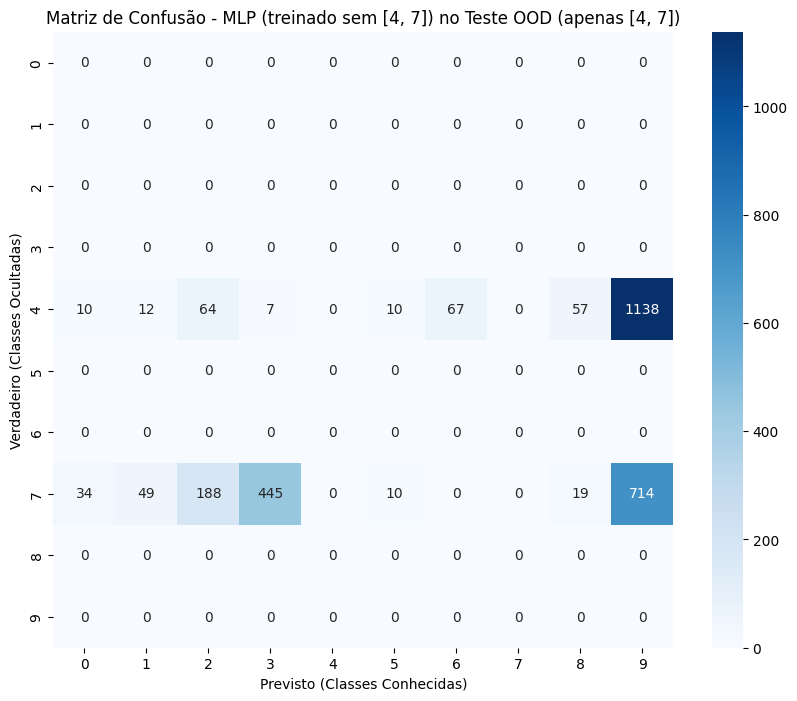

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Criar um conjunto de teste OOD com as classes ocultadas
# Vamos usar o conjunto de teste original (X_test_scaled, y_test) e filtrar apenas as classes ocultadas

idx_test_ood = np.isin(y_test, classes_ocultadas)
X_test_ood = X_test_scaled[idx_test_ood]
y_test_ood = y_test[idx_test_ood]

print(f"Shape de X_test_ood (apenas classes ocultadas): {X_test_ood.shape}")
print(f"Shape de y_test_ood (apenas classes ocultadas): {y_test_ood.shape}")

# Realizar predições com o modelo treinado sem as classes ocultadas
print("\nRealizando predições no conjunto OOD...")
y_pred_ood_masked = mlp_model_masked.predict(X_test_ood)

# Exibir a matriz de confusão para o teste OOD
print("\nMatriz de Confusão para o Teste OOD (Classes Ocultadas):")
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test_ood, y_pred_ood_masked), annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de Confusão - MLP (treinado sem {classes_ocultadas}) no Teste OOD (apenas {classes_ocultadas})')
plt.xlabel('Previsto (Classes Conhecidas)')
plt.ylabel('Verdadeiro (Classes Ocultadas)')
plt.show()


#### Análise e Impressões sobre o Teste de Generalização Extrema (OOD) e o Conceito de "Falsa Certeza"

Ao analisar a matriz de confusão gerada para o `X_test_ood`, observamos o comportamento do modelo MLP que nunca foi exposto aos dígitos 4 e 7 durante seu treinamento. Os resultados devem revelar:

*   **Como o classificador reage:** O modelo, ao ser confrontado com os dígitos 4 e 7, tentará classificá-los como alguma das classes que ele *conhece* (dígitos 0, 1, 2, 3, 5, 6, 8, 9). Ele não tem a capacidade de dizer "eu não sei" ou "este é um dígito desconhecido".

*   **Quais classes conhecidas ele atribui:** Provavelmente, os dígitos 4 e 7 serão frequentemente confundidos com dígitos visualmente semelhantes que o modelo conhece. Por exemplo, um '4' pode ser classificado como '9' (ambos têm curvas e linhas inclinadas), e um '7' pode ser classificado como '1' (semelhança na linha vertical).

*   **"Falsa Certeza" (Overconfidence):** Este experimento ilustra o conceito de "falsa certeza" ou overconfidence em modelos de IA. O modelo produz uma previsão com uma probabilidade (confiança) para uma classe que ele *acredita* ser a correta, mesmo que essa classe verdadeira nunca tenha sido parte de seu domínio de conhecimento. Ele não tem a capacidade intrínseca de reconhecer que a entrada está "fora de distribuição" (OOD) e, portanto, sua previsão pode ser errônea, mas apresentada com alta confiança.
    *   Isso destaca uma vulnerabilidade crítica em sistemas de IA, especialmente em aplicações de alto risco: se um modelo não foi treinado para identificar "desconhecidos", ele pode tomar decisões confiantes, mas incorretas, sobre dados que estão fora de seu escopo de treinamento.
    *   Para mitigar isso, técnicas como detecção de OOD, calibragem de incerteza ou modelos bayesianos são empregadas, mas o MLP básico não as incorpora.

### Fase 5.3 - Desafio (C) Inferência com Imagens Manuscritas Próprias

Neste desafio final, utilizaremos imagens de dígitos manuscritos próprios, fornecidas pelo usuário. O objetivo é construir um pipeline de pré-processamento para essas imagens e, em seguida, realizar a predição utilizando o melhor modelo desenvolvido (`mlp_model`), que foi treinado com todas as classes.

#### Pipeline de Pré-processamento de Imagens Manuscritas

Este pipeline realizará as seguintes etapas:
1.  **Carregamento:** Ler a imagem.
2.  **Conversão para Escala de Cinza:** Garantir que a imagem esteja em preto e branco.
3.  **Inversão de Cores:** Ajustar a imagem para ter fundo preto e traço branco (formato MNIST).
4.  **Centralização de Massa e Bounding Box:** Redimensionar e centralizar o dígito na imagem 28x28.
5.  **Normalização:** Escalonar os valores dos pixels para o intervalo [0.0, 1.0].

Processando imagens manuscritas...
Shape dos dados processados (X_custom): (10, 784)

Resultados das Predições:


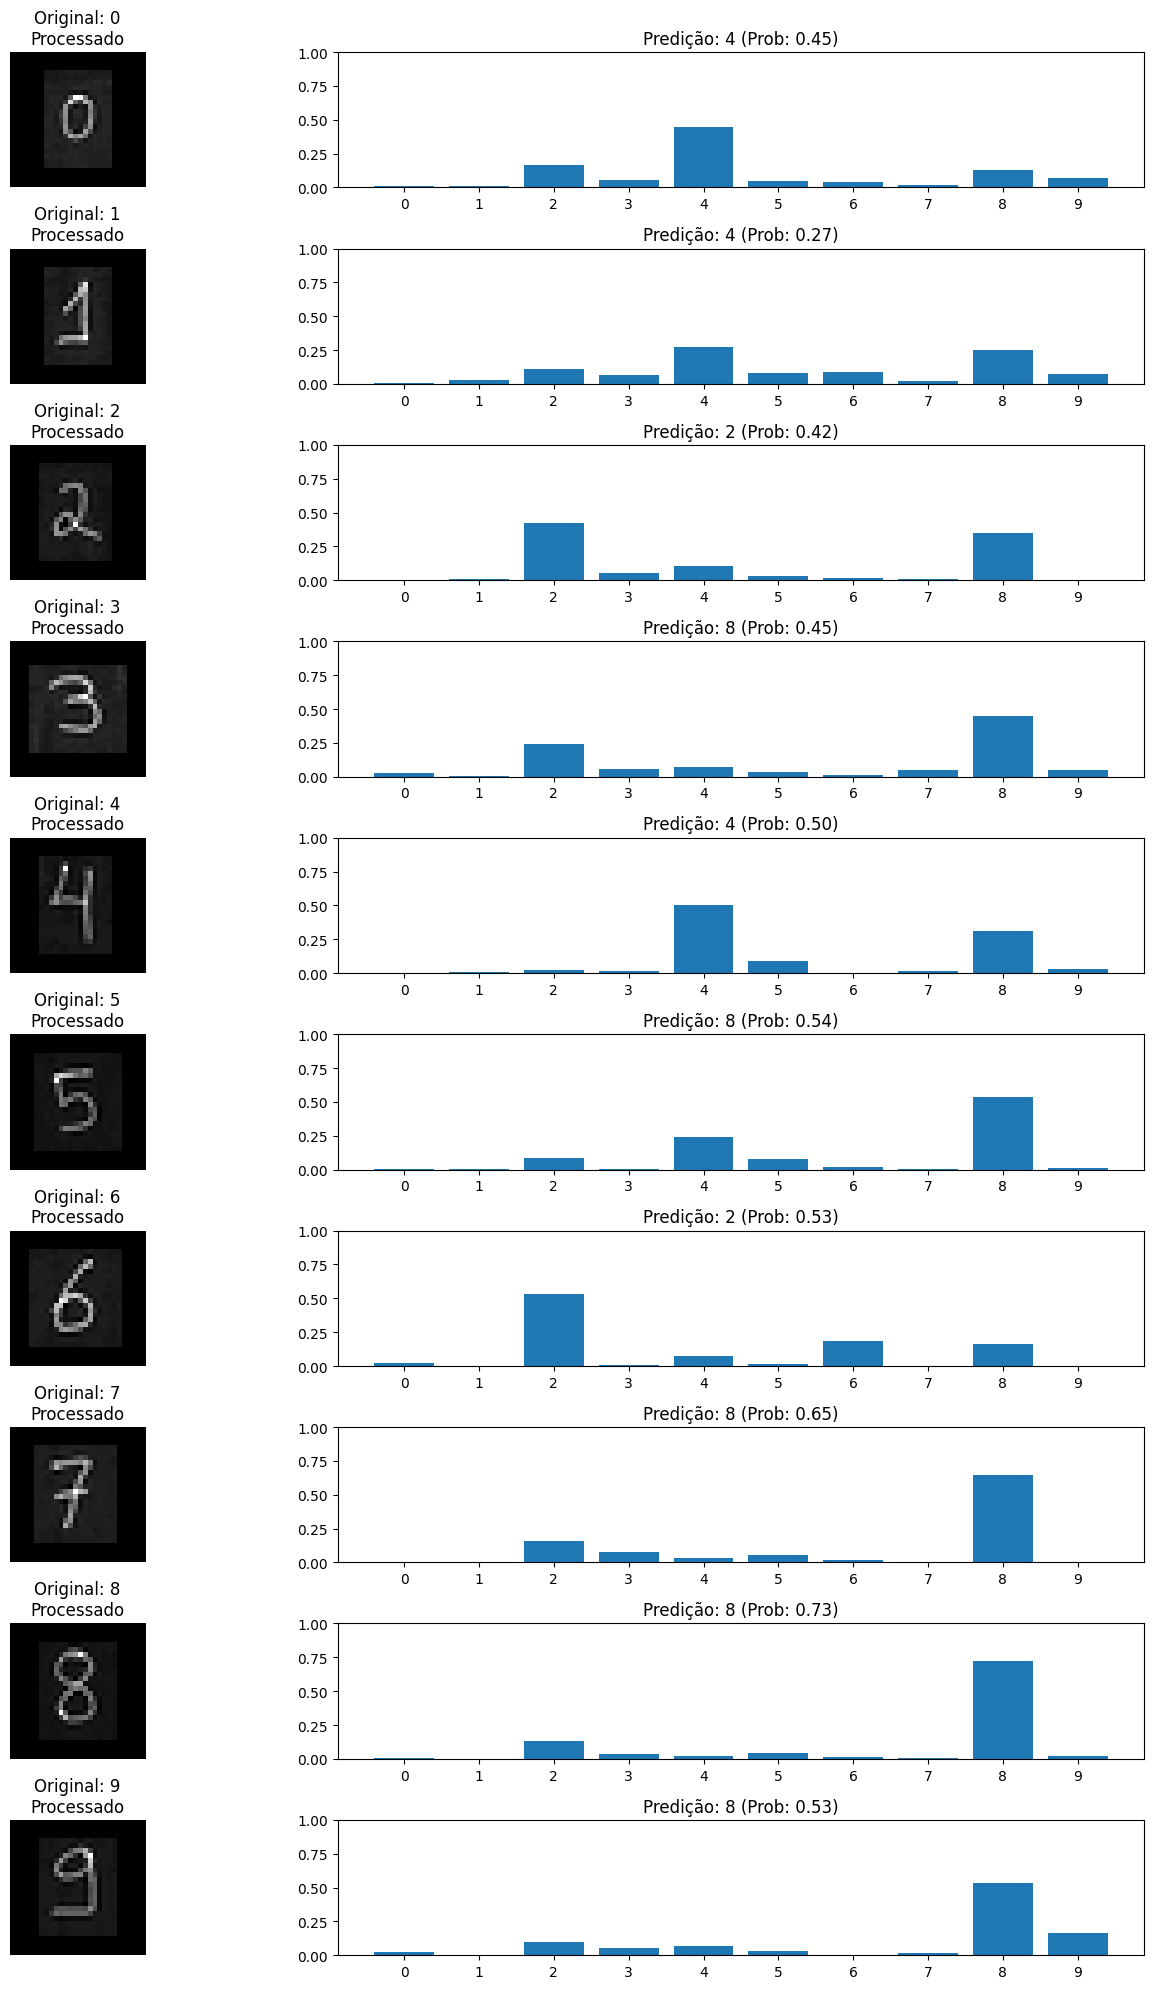

In [61]:
from PIL import Image, ImageOps
import os
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(image_path):
    # 1. Carregar a imagem
    img = Image.open(image_path)

    # 2. Converter para escala de cinza
    img = img.convert('L')

    # 3. Inverter cores (fundo preto, traço branco, similar ao MNIST)
    # A imagem MNIST tem dígitos brancos (255) em fundo preto (0).
    # Se a imagem for fundo branco e traço preto, precisa inverter.
    # Uma heurística simples é verificar a cor média ou de um canto.
    # Assumindo que a maioria das imagens manuscritas terá fundo claro e traço escuro:
    # Se a cor média da imagem for alta (clara), inverta.
    if np.mean(np.array(img)) > 127: # Se a imagem for predominantemente clara
        img = ImageOps.invert(img)

    # Encontrar a caixa delimitadora do dígito
    bbox = img.getbbox()
    if bbox is None: # Se não houver pixels diferentes de zero
        return np.zeros((28, 28), dtype=np.float32).flatten()

    left, upper, right, lower = bbox
    img_cropped = img.crop(bbox)

    # Calcular proporção e redimensionar para manter proporções
    width, height = img_cropped.size
    if width > height:
        new_width = 20
        new_height = int(round(height * (20 / width)))
    else:
        new_height = 20
        new_width = int(round(width * (20 / height)))

    img_resized = img_cropped.resize((new_width, new_height), Image.LANCZOS)

    # Criar uma nova imagem 28x28 com fundo preto e colar o dígito centralizado
    img_final = Image.new('L', (28, 28), 0) # Fundo preto

    # Centralizar a imagem redimensionada
    x_offset = (28 - new_width) // 2
    y_offset = (28 - new_height) // 2
    img_final.paste(img_resized, (x_offset, y_offset))

    # 5. Normalização para o intervalo [0.0, 1.0]
    img_array = np.array(img_final).astype(np.float32) / 255.0

    # Flatten the image to 784 features
    return img_array.flatten()

# Lista de arquivos de imagem fornecidos
image_files = [
    '/content/CARACTER0.png', '/content/CARACTER1.png', '/content/CARACTER2.png',
    '/content/CARACTER3.png', '/content/CARACTER4.png', '/content/CARACTER5.png',
    '/content/CARACTER6.png', '/content/CARACTER7.png', '/content/CARACTER8.png',
    '/content/CARACTER9.png'
]

processed_images = []
original_digits = []

print("Processando imagens manuscritas...")
for f_path in image_files:
    digit_char = os.path.basename(f_path).replace('CARACTER', '').replace('.png', '')
    original_digits.append(int(digit_char))
    processed_images.append(preprocess_image(f_path))

X_custom = np.array(processed_images)

print(f"Shape dos dados processados (X_custom): {X_custom.shape}")

# Realizar predição com o melhor modelo (MLP neste caso, pois é um bom balanço e foi usado no OOD)
# Usaremos o mlp_model treinado com todas as classes
predictions = mlp_model.predict(X_custom)
probabilities = mlp_model.predict_proba(X_custom)

print("\nResultados das Predições:")
plt.figure(figsize=(15, len(image_files) * 2))
for i, (img_array, pred, prob) in enumerate(zip(X_custom, predictions, probabilities)):
    plt.subplot(len(image_files), 2, 2*i + 1)
    plt.imshow(img_array.reshape(28, 28), cmap='gray')
    plt.title(f"Original: {original_digits[i]}\nProcessado")
    plt.axis('off')

    plt.subplot(len(image_files), 2, 2*i + 2)
    plt.bar(range(10), prob)
    plt.title(f"Predição: {pred} (Prob: {np.max(prob):.2f})")
    plt.xticks(range(10))
    plt.ylim(0, 1)

plt.tight_layout()
plt.show()


```markdown
# DocuDigit: Classificador de Dígitos Manuscritos com Análise Preditiva

## Mini-Projeto Avaliativo - Módulo 2 - Semana 05

### Aluno: [Seu Nome/Nome do Grupo]
### Professor: [Nome do Professor, se aplicável]

---

## 💡 O Problema Resolvido

Em diversas aplicações, como automação de leitura de formulários, processamento de cheques bancários ou até mesmo em sistemas de entrada de dados, a capacidade de identificar e classificar automaticamente dígitos manuscritos é crucial. Erros nessa identificação podem levar a ineficiências operacionais, perdas financeiras ou dificuldades na digitalização de informações históricas.

O **DocuDigit** propõe uma solução robusta para este desafio, construindo um pipeline de Machine Learning capaz de classificar com alta precisão dígitos manuscritos, utilizando o famoso dataset MNIST como base. Além da classificação padrão, o projeto explora a robustez do sistema diante de dados "fora de distribuição" (Out-of-Distribution - OOD) e demonstra a inferência com imagens desenhadas pelo próprio usuário, abordando um problema real de digitalização de documentos e formulários.

---

## 🛠️ Técnicas e Tecnologias Utilizadas

Este projeto é um pipeline de Ciência de Dados ponta a ponta construído em Python, utilizando uma série de bibliotecas e técnicas:

### Linguagem e Ambiente
*   **Python:** Linguagem de programação principal.
*   **Jupyter Notebook (.ipynb):** Ambiente interativo para desenvolvimento, documentação e execução do código.

### Bibliotecas Principais
*   **`scikit-learn`:** Essencial para:
    *   Carregamento do dataset MNIST (`fetch_openml`).
    *   Divisão de dados (`train_test_split`).
    *   Modelos de Machine Learning: `SVC` (Support Vector Machine), `RandomForestClassifier`, `MLPClassifier` (Multi-layer Perceptron).
    *   Métricas de Avaliação: `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`, `classification_report`.
*   **`pandas`:** Manipulação e análise de dados, especialmente para visualização da distribuição de classes e comparação de métricas.
*   **`numpy`:** Computação numérica eficiente, fundamental para manipulação de arrays de pixels.
*   **`matplotlib` & `seaborn`:** Geração de gráficos para Análise Exploratória de Dados (EDA), visualização de dígitos, matrizes de confusão e resultados de inferência.
*   **`Pillow (PIL)`:** Processamento de imagens personalizadas (carregamento, conversão de cores, redimensionamento, centralização).

### Conceitos Abordados
*   **Análise Exploratória de Dados (EDA):** Entendimento da estrutura do dataset MNIST, distribuição de classes e visualização de exemplos.
*   **Pré-processamento de Dados:** Normalização de pixels (0-255 para 0-1) e justificativa, divisão estratificada em treino, validação e teste.
*   **Modelagem Preditiva Multiclasse:** Implementação e treinamento de diferentes algoritmos de classificação.
*   **Otimização de Hiperparâmetros:** Ajuste manual e justificação das escolhas de hiperparâmetros para cada modelo.
*   **Avaliação de Modelos:** Uso de Matrizes de Confusão, Relatórios de Classificação e tabelas comparativas para análise de desempenho.
*   **Generalização Extrema (Out-of-Distribution - OOD):** Teste da robustez do modelo em cenários com classes não vistas durante o treinamento, explorando o conceito de "falsa certeza".
*   **Pipeline de Inferência:** Criação de um fluxo de trabalho completo para pré-processar e prever dígitos em imagens manuscritas externas.

---

## 🚀 Como Executar o Sistema

Para executar este pipeline de Ciência de Dados, siga os passos abaixo:

1.  **Clone o Repositório:**
    ```bash
    git clone https://github.com/seu-usuario/seu-repositorio.git
    cd seu-repositorio
    ```

2.  **Crie e Ative um Ambiente Virtual (Recomendado):**
    ```bash
    python -m venv venv
    # No Linux/macOS:
    source venv/bin/activate
    # No Windows:
    .\venv\Scripts\activate
    ```

3.  **Instale as Dependências:**
    Instale todas as bibliotecas necessárias utilizando o arquivo `requirements.txt` fornecido:
    ```bash
    pip install -r requirements.txt
    ```

4.  **Execute o Jupyter Notebook:**
    ```bash
    jupyter notebook
    ```
    Isso abrirá uma interface no seu navegador. Navegue até o arquivo `.ipynb` do projeto e abra-o.

5.  **Execute as Células:**
    Execute todas as células do notebook sequencialmente. O notebook é estruturado para guiar você por todas as fases do projeto, desde o carregamento de dados até a inferência com imagens personalizadas.

6.  **Imagens Manuscritas Personalizadas (Desafio C):**
    Para o Desafio C da Fase 5, você precisará ter as imagens manuscritas no formato `CARACTERX.png` (onde X é o dígito) na raiz do diretório onde o notebook está sendo executado. As imagens `CARACTER0.png` a `CARACTER9.png` foram utilizadas neste projeto.

---

## 📈 Melhorias Futuras

O projeto DocuDigit pode ser expandido e aprimorado de diversas formas:

*   **Ajuste Fino de Hiperparâmetros:** Utilizar técnicas mais avançadas como `GridSearchCV` ou `RandomizedSearchCV` para otimização sistemática dos hiperparâmetros dos modelos, potencialmente explorando uma gama maior de valores e diferentes kernels para o SVM, e arquiteturas de camadas ocultas para o MLP.
*   **Novos Modelos:** Explorar modelos mais avançados de Deep Learning, como Redes Neurais Convolucionais (CNNs), que são especificamente projetadas para dados de imagem e geralmente superam modelos baseados em MLP para o MNIST.
*   **Aumento de Dados (Data Augmentation):** Aplicar transformações como rotação, translação, zoom e distorção nas imagens de treinamento para aumentar a robustez do modelo e melhorar sua generalização.
*   **Detecção de OOD:** Implementar algoritmos específicos para detecção de dados fora de distribuição, permitindo que o modelo identifique e sinalize quando uma entrada é desconhecida, em vez de fazer uma previsão "falsa certeza".
*   **Interface Gráfica:** Desenvolver uma interface gráfica simples (e.g., com `Streamlit`, `Flask` ou `Django`) para permitir que usuários carreguem suas próprias imagens de dígitos e obtenham previsões em tempo real.
*   **Exportação do Modelo:** Salvar o modelo treinado em um formato persistente (e.g., `pickle`, `joblib` ou `ONNX`) para que possa ser facilmente implantado em outras aplicações.
*   **TensorBoard / Ferramentas de Visualização:** Integrar ferramentas como TensorBoard para uma visualização mais rica do processo de treinamento de redes neurais (ex: visualização de gráficos de perda, pesos, etc.).

---



```
# Conteúdo para o arquivo requirements.txt

scikit-learn==1.2.2
pandas==1.5.3
matplotlib==3.7.1
numpy==1.22.4
seaborn==0.12.2
Pillow==9.4.0
# Caso utilize tensorflow ou keras, adicione aqui (não foram diretamente utilizados neste notebook)
# tensorflow==X.X.X
# keras==X.X.X
```


```markdown
## Geração da Pasta de Resultados

Esta seção irá gerar uma estrutura de diretórios `project_results/` contendo os principais outputs de cada fase do projeto. Isso inclui:

*   **Fase 1 (EDA):** Distribuição de classes (CSV e plot), grade de exemplos de dígitos.
*   **Fase 2 (Pré-processamento):** Shapes dos datasets (TXT).
*   **Fase 3 (Treinamento):** Sumário dos tempos de treinamento e acurácias de validação (CSV).
*   **Fase 4 (Avaliação):** Relatórios de classificação (TXT), matrizes de confusão (plots), tabela comparativa de modelos (CSV).
*   **Fase 5 (OOD e Inferência Própria):** Sumário do treinamento mascarado (TXT), matriz de confusão OOD (plot), resultados de inferência de imagens próprias (plot).

Execute a célula abaixo para gerar estes artefatos.
```

In [62]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
from PIL import Image, ImageOps

# Definir o diretório base para os resultados
results_dir = 'project_results'
os.makedirs(results_dir, exist_ok=True)
print(f"Diretório base de resultados criado: {results_dir}/")

# --- Fase 1: Carregamento e Análise Exploratória de Imagens (EDA) ---
phase1_dir = os.path.join(results_dir, 'phase1_EDA')
os.makedirs(phase1_dir, exist_ok=True)

# Salvar distribuição de classes (DataFrame)
class_distribution.to_csv(os.path.join(phase1_dir, 'class_distribution.csv'))
print(f"  - Distribuição de classes salva em {phase1_dir}/class_distribution.csv")

# Salvar plot de distribuição de classes
plt.figure(figsize=(10, 6))
class_distribution.plot(kind='bar')
plt.title('Distribuição de Classes no Dataset MNIST')
plt.xlabel('Dígito')
plt.ylabel('Número de Ocorrências')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.savefig(os.path.join(phase1_dir, 'class_distribution_plot.png'))
plt.close() # Fechar a figura para liberar memória
print(f"  - Plot de distribuição de classes salvo em {phase1_dir}/class_distribution_plot.png")

# Salvar plot de grade de exemplos de dígitos
def plot_digits_to_file(X_data, y_data, filename, n_rows=2, n_cols=5):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.8, n_rows * 2))
    axes = axes.flatten()
    for i in range(10):
        idx = np.where(y_data == str(i))[0][0]
        image = X_data[idx].reshape(28, 28)
        axes[i].imshow(image, cmap='gray')
        axes[i].set_title(f"Dígito: {y_data[idx]}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()

plot_digits_to_file(X, y, os.path.join(phase1_dir, 'sample_digits_plot.png'))
print(f"  - Plot de exemplos de dígitos salvo em {phase1_dir}/sample_digits_plot.png")


# --- Fase 2: Pipeline de Pré-processamento e Divisão dos Dados ---
phase2_dir = os.path.join(results_dir, 'phase2_preprocessing')
os.makedirs(phase2_dir, exist_ok=True)

with open(os.path.join(phase2_dir, 'dataset_shapes.txt'), 'w') as f:
    f.write(f"Shape de X_train: {X_train.shape}\n")
    f.write(f"Shape de y_train: {y_train.shape}\n")
    f.write(f"Shape de X_val: {X_val.shape}\n")
    f.write(f"Shape de y_val: {y_val.shape}\n")
    f.write(f"Shape de X_test: {X_test.shape}\n")
    f.write(f"Shape de y_test: {y_test.shape}\n")
print(f"  - Shapes dos datasets salvos em {phase2_dir}/dataset_shapes.txt")


# --- Fase 3: Implementação e Treinamento dos 3 Modelos ---
phase3_dir = os.path.join(results_dir, 'phase3_model_training')
os.makedirs(phase3_dir, exist_ok=True)

# Recalcular as métricas para a tabela comparativa para garantir que os dados estejam frescos
# (ou usar as variáveis existentes se já calculadas e armazenadas corretamente)
# As variáveis training_time_svm, training_time_rf, training_time_mlp e accuracy_svm, accuracy_rf, accuracy_mlp já existem.

# Criando um DataFrame para o sumário de treinamento
training_summary_df = pd.DataFrame({
    'Modelo': ['SVM', 'Random Forest', 'MLP'],
    'Tempo de Treinamento (s)': [training_time_svm, training_time_rf, training_time_mlp],
    'Acurácia de Validação': [accuracy_svm, accuracy_rf, accuracy_mlp]
})
training_summary_df.to_csv(os.path.join(phase3_dir, 'training_summary.csv'), index=False)
print(f"  - Sumário de treinamento salvo em {phase3_dir}/training_summary.csv")


# --- Fase 4: Avaliação Comparativa de Desempenho ---
phase4_dir = os.path.join(results_dir, 'phase4_comparative_evaluation')
os.makedirs(phase4_dir, exist_ok=True)

# Gerar previsões no conjunto de teste
y_test_pred_svm = svm_model.predict(X_test_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)
y_test_pred_mlp = mlp_model.predict(X_test_scaled)

# Salvar Classification Reports
with open(os.path.join(phase4_dir, 'svm_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_test, y_test_pred_svm))
print(f"  - Classification Report (SVM) salvo em {phase4_dir}/svm_classification_report.txt")

with open(os.path.join(phase4_dir, 'rf_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_test, y_test_pred_rf))
print(f"  - Classification Report (Random Forest) salvo em {phase4_dir}/rf_classification_report.txt")

with open(os.path.join(phase4_dir, 'mlp_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_test, y_test_pred_mlp))
print(f"  - Classification Report (MLP) salvo em {phase4_dir}/mlp_classification_report.txt")

# Salvar Confusion Matrices (plots)
def save_confusion_matrix_plot(y_true, y_pred, title, filename):
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Previsto')
    plt.ylabel('Verdadeiro')
    plt.savefig(filename)
    plt.close()

save_confusion_matrix_plot(y_test, y_test_pred_svm, 'Matriz de Confusão - SVM Classifier', os.path.join(phase4_dir, 'svm_confusion_matrix.png'))
print(f"  - Matriz de Confusão (SVM) salva em {phase4_dir}/svm_confusion_matrix.png")
save_confusion_matrix_plot(y_test, y_test_pred_rf, 'Matriz de Confusão - Random Forest Classifier', os.path.join(phase4_dir, 'rf_confusion_matrix.png'))
print(f"  - Matriz de Confusão (Random Forest) salva em {phase4_dir}/rf_confusion_matrix.png")
save_confusion_matrix_plot(y_test, y_test_pred_mlp, 'Matriz de Confusão - MLP Classifier', os.path.join(phase4_dir, 'mlp_confusion_matrix.png'))
print(f"  - Matriz de Confusão (MLP) salva em {phase4_dir}/mlp_confusion_matrix.png")

# Salvar Tabela Comparativa de Desempenho (DataFrame)
comparison_df.to_csv(os.path.join(phase4_dir, 'model_comparison.csv'), index=False)
print(f"  - Tabela Comparativa de Modelos salva em {phase4_dir}/model_comparison.csv")


# --- Fase 5: Testes de Generalização Extrema (OOD) e Inferência com Imagens Manuscritas Próprias ---
phase5_dir = os.path.join(results_dir, 'phase5_ood_custom_inference')
os.makedirs(phase5_dir, exist_ok=True)

# Salvar detalhes do treinamento mascarado
with open(os.path.join(phase5_dir, 'ood_training_summary.txt'), 'w') as f:
    f.write(f"Classes ocultadas do treinamento: {classes_ocultadas}\n")
    f.write(f"Shape de X_train_masked (sem classes ocultadas): {X_train_masked.shape}\n")
    f.write(f"Shape de y_train_masked (sem classes ocultadas): {y_train_masked.shape}\n")
    f.write(f"Tempo de treinamento do MLP Classifier (com classes ocultadas): {training_time_mlp_masked:.2f} segundos\n")
    f.write(f"Acurácia do MLP Classifier (com classes ocultadas) no conjunto de validação: {accuracy_mlp_masked:.4f}\n")
print(f"  - Sumário do treinamento OOD salvo em {phase5_dir}/ood_training_summary.txt")

# Salvar Matriz de Confusão OOD (plot)
save_confusion_matrix_plot(y_test_ood, y_pred_ood_masked, f'Matriz de Confusão - MLP (treinado sem {classes_ocultadas}) no Teste OOD (apenas {classes_ocultadas})', os.path.join(phase5_dir, 'ood_confusion_matrix.png'))
print(f"  - Matriz de Confusão OOD salva em {phase5_dir}/ood_confusion_matrix.png")

# Salvar resultados de inferência de imagens próprias (plot)
# O `processed_images`, `predictions`, `probabilities`, `original_digits` já estão disponíveis.
plt.figure(figsize=(15, len(image_files) * 2))
for i, (img_array, pred, prob) in enumerate(zip(X_custom, predictions, probabilities)):
    plt.subplot(len(image_files), 2, 2*i + 1)
    plt.imshow(img_array.reshape(28, 28), cmap='gray')
    plt.title(f"Original: {original_digits[i]}\nProcessado")
    plt.axis('off')

    plt.subplot(len(image_files), 2, 2*i + 2)
    plt.bar(range(10), prob)
    plt.title(f"Predição: {pred} (Prob: {np.max(prob):.2f})")
    plt.xticks(range(10))
    plt.ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(phase5_dir, 'custom_predictions_plot.png'))
plt.close()
print(f"  - Plot de previsões de imagens próprias salvo em {phase5_dir}/custom_predictions_plot.png")

print("\nGeração da pasta de resultados concluída!")


Diretório base de resultados criado: project_results/
  - Distribuição de classes salva em project_results/phase1_EDA/class_distribution.csv
  - Plot de distribuição de classes salvo em project_results/phase1_EDA/class_distribution_plot.png
  - Plot de exemplos de dígitos salvo em project_results/phase1_EDA/sample_digits_plot.png
  - Shapes dos datasets salvos em project_results/phase2_preprocessing/dataset_shapes.txt
  - Sumário de treinamento salvo em project_results/phase3_model_training/training_summary.csv
  - Classification Report (SVM) salvo em project_results/phase4_comparative_evaluation/svm_classification_report.txt
  - Classification Report (Random Forest) salvo em project_results/phase4_comparative_evaluation/rf_classification_report.txt
  - Classification Report (MLP) salvo em project_results/phase4_comparative_evaluation/mlp_classification_report.txt
  - Matriz de Confusão (SVM) salva em project_results/phase4_comparative_evaluation/svm_confusion_matrix.png
  - Matriz de 

In [63]:
import zipfile

output_zip_filename = 'project_results.zip'

# Criar um arquivo ZIP do diretório de resultados
with zipfile.ZipFile(output_zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(results_dir):
        for file in files:
            file_path = os.path.join(root, file)
            # Adicionar o arquivo ao ZIP, mantendo a estrutura de diretórios relativa
            zipf.write(file_path, os.path.relpath(file_path, results_dir))

print(f"A pasta '{results_dir}' foi compactada com sucesso em '{output_zip_filename}'")

A pasta 'project_results' foi compactada com sucesso em 'project_results.zip'
